### b = 3.0, gs1 = 3, gcm = 2.2, k = 16, 500/500

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
beta = 3.0
gamma_s1 = 3.0
gamma_cm = 2.2

In [3]:
# Cargar el archivo rewiring
rewiring_file = 'clustering_rewiring_sample1.dat'
df_rewiring = pd.read_csv(rewiring_file, delim_whitespace=True, header=None, names=['node','degree', 'clustering'])

# Eliminar valores NaN
df_rewiring.dropna(inplace=True)

# Asegurarse de que los valores de 'degree' y 'clustering' sean numéricos
df_rewiring['degree'] = pd.to_numeric(df_rewiring['degree'], errors='coerce')
df_rewiring['clustering'] = pd.to_numeric(df_rewiring['clustering'], errors='coerce')

# Eliminar cualquier fila que tenga NaN después de la conversión
df_rewiring.dropna(inplace=True)

# Grados de interés
degrees_of_interest = [5, 20]

# Crear un diccionario para almacenar histogramas y PDFs
histograms = {}
pdfs = {}

# Filtrar y calcular para los grados de interés
for degree in degrees_of_interest:
    # Filtrar por degree
    clustering_values = df_rewiring[df_rewiring['degree'] == degree]['clustering']
    
    # Eliminar NaN en clustering_values
    clustering_values = clustering_values.dropna()
    
    # Verificar que clustering_values tenga suficientes elementos y varianza no nula
    if len(clustering_values) > 1 and np.var(clustering_values) > 0:
        # Calcular el histograma con 20 divisiones
        hist, bins = np.histogram(clustering_values, bins=20, density=True)
        histograms[degree] = (hist, bins)
        
        # Calcular la PDF
        kde = gaussian_kde(clustering_values)
        pdfs[degree] = kde

# Graficar los histogramas y PDFs para cada degree de interés
for degree in degrees_of_interest:
    if degree in histograms:
        hist, bins = histograms[degree]
        kde = pdfs[degree]
        
        

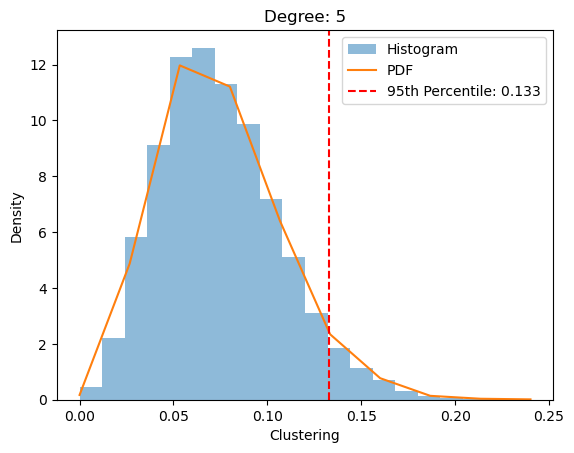

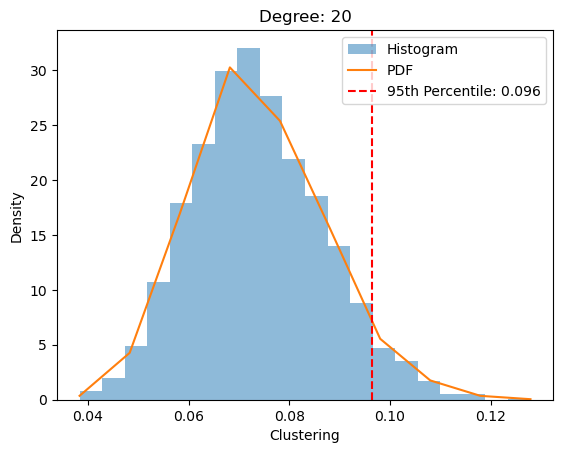

In [4]:
# Crear un diccionario para almacenar el valor del percentil
percentiles = {}

# Calcular y mostrar el valor del percentil para cada grado de interés
for degree in degrees_of_interest:
    # Filtrar por degree
    clustering_values = df_rewiring[df_rewiring['degree'] == degree]['clustering']
    
    # Eliminar NaN en clustering_values
    clustering_values = clustering_values.dropna()
    
    # Verificar que clustering_values tenga suficientes elementos y varianza no nula
    if len(clustering_values) > 1 and np.var(clustering_values) > 0:
        # Calcular el percentil 95 (es decir, el valor debajo del cual se encuentra el 95% de los datos)
        percentile_value = np.percentile(clustering_values, 95)
        percentiles[degree] = percentile_value
        
        # Mostrar el percentil en el gráfico
        hist, bins = histograms[degree]
        kde = pdfs[degree]
        
        plt.figure()
        plt.hist(bins[:-1], bins,  density=True, weights=hist, alpha=0.5, label='Histogram')
        x_range = np.linspace(bins[0], bins[-1], 10)
        plt.plot(x_range, kde(x_range), label='PDF')
        plt.axvline(percentile_value, color='r', linestyle='--', label=f'95th Percentile: {percentile_value:.3f}')
        plt.title(f'Degree: {degree}')
        plt.xlabel('Clustering')
        plt.ylabel('Density')
        plt.legend()
        plt.show()

In [5]:
# Mostrar los valores de percentil
print("Valores de percentil 95 para cada grado de interés:")
for degree, value in percentiles.items():
    print(f"Degree {degree}: {value}")

Valores de percentil 95 para cada grado de interés:
Degree 5: 0.13264354999999997
Degree 20: 0.09645254999999997


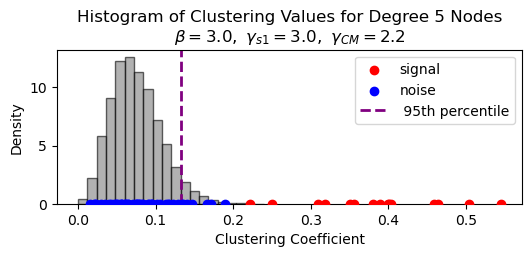

In [6]:
#fig 1

# Cargar el archivo sample
sample_file = 'clustering_sample1.dat'
df_sample = pd.read_csv(sample_file, delim_whitespace=True, header=None, names=['node','class', 'degree', 'clustering'])

# Eliminar valores NaN
df_sample.dropna(inplace=True)

# Asegurarse de que los valores de 'degree' y 'clustering' sean numéricos
df_sample['degree'] = pd.to_numeric(df_sample['degree'], errors='coerce')
df_sample['clustering'] = pd.to_numeric(df_sample['clustering'], errors='coerce')

# Eliminar cualquier fila que tenga NaN después de la conversión
df_sample.dropna(inplace=True)
# Filtrar los datos por degree 5
rewiring_degree_5 = df_rewiring[df_rewiring['degree'] == 5]
sample_degree_5 = df_sample[df_sample['degree'] == 5]

# Obtener los valores de clustering de nodos de clase 1 y 2 del archivo sample0
sample_class_1 = sample_degree_5[sample_degree_5['class'] == 1]['clustering']
sample_class_2 = sample_degree_5[sample_degree_5['class'] == 2]['clustering']

# Calcular el histograma de los valores de clustering para los nodos de grado 5 en el archivo rewiring
hist, bins = np.histogram(rewiring_degree_5['clustering'], bins=20, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Calcular los percentiles 2.5 y 97.5

percentil_95 = 0.133
# Dibujar el histograma
plt.figure(figsize=(6, 2))
plt.hist(rewiring_degree_5['clustering'], bins=20, density=True, alpha=0.6, color='gray', edgecolor='black')

# Añadir puntos rojos para los valores de clustering de nodos de clase 1
plt.scatter(sample_class_1, np.zeros_like(sample_class_1), color='red', label='signal', zorder=5)

# Añadir puntos azules para los valores de clustering de nodos de clase 2
plt.scatter(sample_class_2, np.zeros_like(sample_class_2), color='blue', label='noise', zorder=5)

# Añadir líneas punteadas para los percentiles
#plt.axvline(percentil_2_5, color='green', linestyle='dashed', linewidth=2, label='Percentil 2.5')
plt.axvline(percentil_95 , label=r' 95th percentile', color='purple', linestyle='dashed', linewidth=2)

# Añadir leyenda
plt.legend()

plt.title(
    rf'Histogram of Clustering Values for Degree 5 Nodes'
    '\n'
    rf'$\beta={beta},\ \gamma_{{s1}}={gamma_s1},\ \gamma_{{CM}}={gamma_cm}$'
)
plt.xlabel('Clustering Coefficient')
plt.ylabel('Density')

# Mostrar el gráfico
fig1 = plt.gcf()
plt.show()

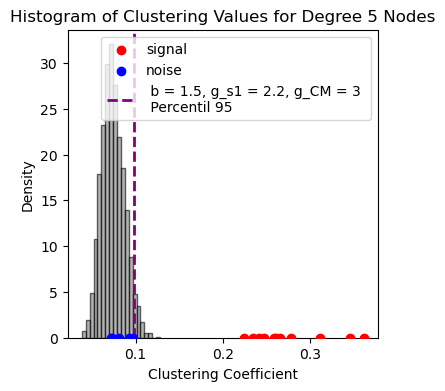

In [7]:
# Filtrar los datos por degree 5
rewiring_degree_5 = df_rewiring[df_rewiring['degree'] == 20]
sample_degree_5 = df_sample[df_sample['degree'] == 20]


# Obtener los valores de clustering de nodos de clase 1 y 2 del archivo sample0
sample_class_1 = sample_degree_5[sample_degree_5['class'] == 1]['clustering']
sample_class_2 = sample_degree_5[sample_degree_5['class'] == 2]['clustering']

# Calcular el histograma de los valores de clustering para los nodos de grado 5 en el archivo rewiring
hist, bins = np.histogram(rewiring_degree_5['clustering'], bins=20, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Calcular los percentiles 2.5 y 97.5

percentil_95 = 0.098
# Dibujar el histograma
plt.figure(figsize=(4, 4))
plt.hist(rewiring_degree_5['clustering'], bins=20, density=True, alpha=0.6, color='gray', edgecolor='black')

# Añadir puntos rojos para los valores de clustering de nodos de clase 1
plt.scatter(sample_class_1, np.zeros_like(sample_class_1), color='red', label='signal', zorder=5)

# Añadir puntos azules para los valores de clustering de nodos de clase 2
plt.scatter(sample_class_2, np.zeros_like(sample_class_2), color='blue', label='noise', zorder=5)

# Añadir líneas punteadas para los percentiles
#plt.axvline(percentil_2_5, color='green', linestyle='dashed', linewidth=2, label='Percentil 2.5')
plt.axvline(percentil_95 , label=' b = 1.5, g_s1 = 2.2, g_CM = 3 \n Percentil 95' , color='purple', linestyle='dashed', linewidth=2)

# Añadir leyenda
plt.legend()

# Añadir título y etiquetas
plt.title('Histogram of Clustering Values for Degree 5 Nodes')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Density')

# Mostrar el gráfico
plt.show()

In [8]:
# Obtener todos los grados únicos del archivo rewiring
degrees_of_interest = df_rewiring['degree'].unique()

# Crear diccionarios para almacenar percentiles
percentiles = {50: {}, 55: {}, 60: {}, 65: {}, 70: {}, 75: {}, 80: {}, 85: {}, 90: {}, 95: {}, 99: {}, 99.9: {}, 100: {}}

# Calcular percentiles para cada grado
for degree in degrees_of_interest:
    clustering_values = df_rewiring[df_rewiring['degree'] == degree]['clustering']
    if len(clustering_values) > 0:
        for threshold in percentiles.keys():
            percentiles[threshold][degree] = np.percentile(clustering_values, threshold)
    else:
        for threshold in percentiles.keys():
            percentiles[threshold][degree] = None

# Obtener el total de nodos de clase 1 y clase 2 en el DataFrame original
total_class_1_original = df_sample[df_sample['class'] == 1].shape[0]
total_class_2_original = df_sample[df_sample['class'] == 2].shape[0]

# Crear lista para almacenar los resultados
results = []

# Función para calcular y mostrar los resultados para un percentil dado, incluyendo cálculo del signal-to-noise
def calculate_and_display_results_with_signal_to_noise(df_sample, percentiles, threshold, total_class_1_original, total_class_2_original):
    total_class_1_within_threshold = 0
    total_class_2_within_threshold = 0
    total_class_1 = 0
    total_class_2 = 0

    df_sample[f'within_{threshold}'] = False

    for degree in degrees_of_interest:
        if degree in percentiles[threshold] and percentiles[threshold][degree] is not None:
            percentile_value = percentiles[threshold][degree]
            
            sample_degree = df_sample[df_sample['degree'] == degree]
            
            for class_label in [1, 2]:
                class_values = sample_degree[sample_degree['class'] == class_label]
                
                count_within_percentile = np.sum(class_values['clustering'] <= percentile_value)
                total_count = len(class_values)
                
                if class_label == 1:
                    total_class_1 += total_count
                    total_class_1_within_threshold += count_within_percentile
                elif class_label == 2:
                    total_class_2 += total_count
                    total_class_2_within_threshold += count_within_percentile
                
                df_sample.loc[class_values.index, f'within_{threshold}'] = class_values['clustering'] <= percentile_value



    # Calcular signal-to-noise
    signal_to_noise = (total_class_1_original - total_class_1_within_threshold) / (total_class_2_original - total_class_2_within_threshold) if (total_class_2_original - total_class_2_within_threshold) != 0 else float('inf')

    # Guardar resultados en la lista
    results.append([threshold, total_class_1_within_threshold, total_class_2_within_threshold, signal_to_noise])

   # print(f"Threshold {threshold}th Percentile:")
   # print(f"Class 1: {total_class_1_within_threshold} nodes within the {threshold}th percentile")
   # print(f"Class 2: {total_class_2_within_threshold} nodes within the {threshold}th percentile")
   # print(f"Removed Class 1: {removed_class1}, Removed Class 2: {removed_class2}")
   # print(f"Signal-to-Noise: {signal_to_noise:.2f}\n")

# Calcular y mostrar resultados para percentiles
for threshold in [50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 99, 99.9, 100]:
    calculate_and_display_results_with_signal_to_noise(df_sample, percentiles, threshold, total_class_1_original, total_class_2_original)

# Crear un DataFrame con los resultados
df_results = pd.DataFrame(results, columns=['pvalue', 'removed_class1', 'removed_class2', 'signal_to_noise'])

# Guardar los resultados en un archivo .dat
output_file = 'remotion.dat'
df_results.to_csv(output_file, sep='\t', index=False, header=False)

print(f"Resultados guardados en {output_file}")


Resultados guardados en remotion.dat


In [9]:
# Lista para almacenar los resultados incluyendo métricas de la matriz de confusión y F1-Score
results = []

# Función para calcular y mostrar los resultados con matriz de confusión y F1-Score
def calculate_metrics_with_confusion_and_fscore(df_sample, percentiles, threshold, total_class_1_original, total_class_2_original):
    total_class_1_within_threshold = 0
    total_class_2_within_threshold = 0
    total_class_1 = 0
    total_class_2 = 0

    df_sample[f'within_{threshold}'] = False

    for degree in degrees_of_interest:
        if degree in percentiles[threshold] and percentiles[threshold][degree] is not None:
            percentile_value = percentiles[threshold][degree]
            
            sample_degree = df_sample[df_sample['degree'] == degree]
            
            for class_label in [1, 2]:
                class_values = sample_degree[sample_degree['class'] == class_label]
                
                count_within_percentile = np.sum(class_values['clustering'] <= percentile_value)
                total_count = len(class_values)
                
                if class_label == 1:
                    total_class_1 += total_count
                    total_class_1_within_threshold += count_within_percentile
                elif class_label == 2:
                    total_class_2 += total_count
                    total_class_2_within_threshold += count_within_percentile
                
                df_sample.loc[class_values.index, f'within_{threshold}'] = class_values['clustering'] <= percentile_value

    # Calcular nodos removidos de cada clase
    removed_class1 =  total_class_1_within_threshold
    removed_class2 = total_class_2_within_threshold

    # Calcular signal-to-noise
    signal_to_noise = (total_class_1 - removed_class1) / (total_class_2 - removed_class2) if (total_class_2 - removed_class2) != 0 else float('inf')

    # Calcular métricas de la matriz de confusión
    tp = total_class_2_within_threshold  # True positives: Class 2 within the cluster
    fp = total_class_1_within_threshold  # False positives: Class 1 within the cluster
    tn = total_class_1_original - total_class_1_within_threshold  # True negatives
    fn = total_class_2_original - total_class_2_within_threshold  # False negatives

    # Calcular precision, recall y F1-Score
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Guardar resultados en la lista
    results.append([threshold, removed_class1, removed_class2, signal_to_noise, tp, fp, tn, fn, precision, recall, f1_score])

    # Mostrar resultados
    print(f"Threshold {threshold}th Percentile:")
    print(f"Confusion Matrix:")
    print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
    print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}")
    print(f"Signal-to-Noise: {signal_to_noise:.2f}\n")

# Calcular y mostrar resultados para cada percentil
for threshold in [90, 95, 99]:
    calculate_metrics_with_confusion_and_fscore(df_sample, percentiles, threshold, total_class_1_original, total_class_2_original)

# Crear un DataFrame con los resultados
columns = [
    'pvalue', 'removed_class1', 'removed_class2', 'signal_to_noise',
    'true_positive', 'false_positive', 'true_negative', 'false_negative',
    'precision', 'recall', 'f1_score'
]
df_results = pd.DataFrame(results, columns=columns)

# Guardar los resultados en un archivo .dat
output_file = 'remotion_with_metrics.dat'
df_results.to_csv(output_file, sep='\t', index=False, header=True)

print(f"Resultados guardados en {output_file}")


Threshold 90th Percentile:
Confusion Matrix:
TP: 434, FP: 0, TN: 500, FN: 56
Precision: 1.00, Recall: 0.89, F1-Score: 0.94
Signal-to-Noise: 8.93

Threshold 95th Percentile:
Confusion Matrix:
TP: 459, FP: 0, TN: 500, FN: 31
Precision: 1.00, Recall: 0.94, F1-Score: 0.97
Signal-to-Noise: 16.13

Threshold 99th Percentile:
Confusion Matrix:
TP: 482, FP: 0, TN: 500, FN: 8
Precision: 1.00, Recall: 0.98, F1-Score: 0.99
Signal-to-Noise: 62.50

Resultados guardados en remotion_with_metrics.dat


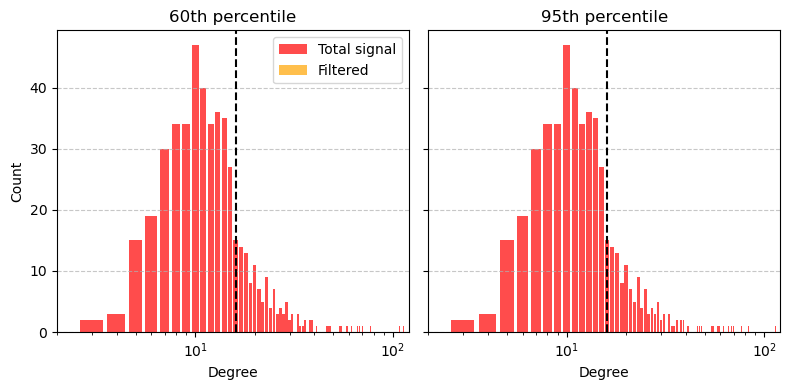

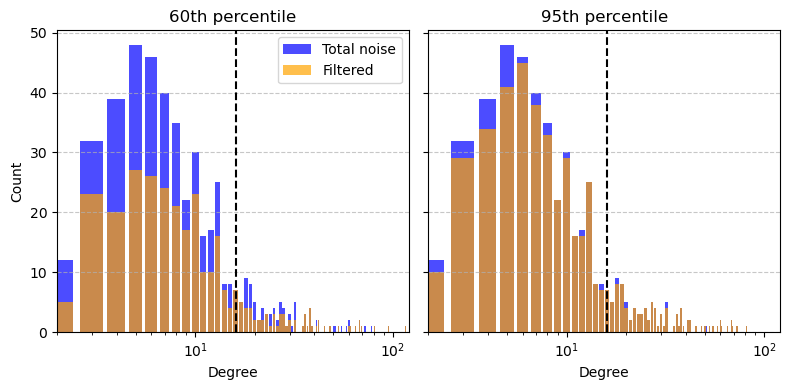

In [10]:
# fig 2

pvalues_to_plot = [60, 95]

def plot_histograms_side_by_side(df_sample, percentiles, pvalues, node_class, 
                                 total_label, total_color):
    degrees = np.sort(df_sample['degree'].unique())

    fig, axes = plt.subplots(1, len(pvalues), figsize=(8, 4), sharey=True)

    for ax, threshold in zip(axes, pvalues):
        total_counts = []
        filtered_counts = []

        for degree in degrees:
            nodes = df_sample[
                (df_sample['degree'] == degree) &
                (df_sample['class'] == node_class)
            ]

            total_counts.append(len(nodes))

            if degree in percentiles[threshold]:
                percentile_value = percentiles[threshold][degree]
                filtered_count = np.sum(
                    nodes['clustering'] <= percentile_value
                )
            else:
                filtered_count = 0

            filtered_counts.append(filtered_count)

        ax.bar(degrees, total_counts, alpha=0.7,
               label=total_label, color=total_color)
        ax.bar(degrees, filtered_counts, alpha=0.7,
               label='Filtered', color='orange')

        ax.set_xscale('log')
        ax.set_xlim(2, 120)
        ax.axvline(x=16, linestyle='--', linewidth=1.5, color='black')
        
        ax.set_xlabel('Degree')
        ax.set_title(f'{threshold}th percentile')
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    axes[0].set_ylabel('Count')
    axes[0].legend()

    
    plt.tight_layout()
    plt.show()
    return fig


# ---- Calls ----
fig2_signal = plot_histograms_side_by_side(
    df_sample, percentiles, pvalues_to_plot,
    node_class=1,
    total_label='Total signal',
    total_color='red'
)

fig2_noise = plot_histograms_side_by_side(
    df_sample, percentiles, pvalues_to_plot,
    node_class=2,
    total_label='Total noise',
    total_color='blue'
)

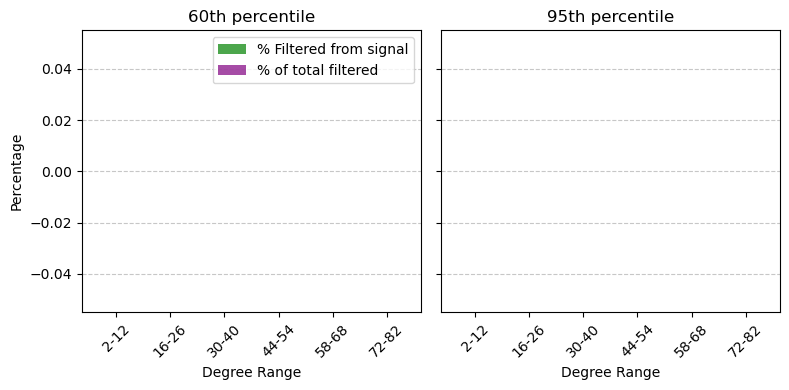

In [11]:
def plot_filtered_percentages_side_by_side(df_sample, percentiles, pvalues):
    fig, axes = plt.subplots(1, len(pvalues), figsize=(8, 4), sharey=True)

    for ax, threshold in zip(axes, pvalues):
        total_counts = []
        filtered_counts = []

        degrees = np.sort(df_sample['degree'].unique())

        degree_ranges = range(2, 60 + 14, 14)
        filtered_percentages = []
        feature_percentages = []

        total_features_filtered = 0

        for degree in degrees:
            type1_nodes = df_sample[
                (df_sample['degree'] == degree) &
                (df_sample['class'] == 1)
            ]

            total_counts.append(len(type1_nodes))

            if degree in percentiles[threshold]:
                percentile_value = percentiles[threshold][degree]
                filtered_count = np.sum(
                    type1_nodes['clustering'] <= percentile_value
                )
            else:
                filtered_count = 0

            filtered_counts.append(filtered_count)
            total_features_filtered += filtered_count

        for start in degree_ranges:
            end = start + 10
            total_in_range = sum(
                total_counts[i] for i, d in enumerate(degrees)
                if start <= d < end
            )
            filtered_in_range = sum(
                filtered_counts[i] for i, d in enumerate(degrees)
                if start <= d < end
            )

            percentage_filtered = (
                filtered_in_range / total_in_range * 100
                if total_in_range > 0 else 0
            )
            feature_percentage = (
                filtered_in_range / total_features_filtered * 100
                if total_features_filtered > 0 else 0
            )

            filtered_percentages.append(percentage_filtered)
            feature_percentages.append(feature_percentage)

        ranges = [f"{start}-{start+10}" for start in degree_ranges]
        x = np.arange(len(ranges))
        width = 0.35

        ax.bar(
            x - width / 2, filtered_percentages, width,
            label='% Filtered from signal',
            color='green', alpha=0.7
        )
        ax.bar(
            x + width / 2, feature_percentages, width,
            label='% of total filtered',
            color='purple', alpha=0.7
        )

        ax.set_title(f'{threshold}th percentile')
        ax.set_xlabel('Degree Range')
        ax.set_xticks(x)
        ax.set_xticklabels(ranges, rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    axes[0].set_ylabel('Percentage')
    axes[0].legend()

    plt.tight_layout()
    plt.show()
    
pvalues_to_plot = [60, 95]
plot_filtered_percentages_side_by_side(df_sample, percentiles, pvalues_to_plot)

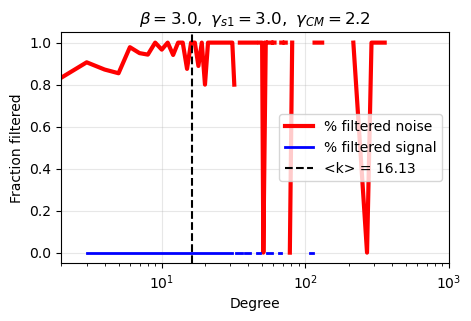

In [12]:
#fig 3

threshold = 95

degrees = np.sort(df_sample['degree'].unique())

perc_filtered_signal = []
perc_filtered_noise = []

for degree in degrees:
    signal_nodes = df_sample[(df_sample['degree'] == degree) & (df_sample['class'] == 1)]
    noise_nodes  = df_sample[(df_sample['degree'] == degree) & (df_sample['class'] == 2)]

    if degree in percentiles[threshold]:
        perc_value = percentiles[threshold][degree]

        # signal (class 1)
        if len(signal_nodes) > 0:
            filtered_signal = np.sum(signal_nodes['clustering'] <= perc_value)
            perc_filtered_signal.append(filtered_signal / len(signal_nodes))
        else:
            perc_filtered_signal.append(np.nan)

        # noise (class 2)
        if len(noise_nodes) > 0:
            filtered_noise = np.sum(noise_nodes['clustering'] <= perc_value)
            perc_filtered_noise.append(filtered_noise / len(noise_nodes))
        else:
            perc_filtered_noise.append(np.nan)

    else:
        perc_filtered_signal.append(np.nan)
        perc_filtered_noise.append(np.nan)

# ---- GRADOS MEDIOS (líneas verticales) ----
# 1) grado medio de toda la red (promedio por nodo)
k_mean_network = df_sample['degree'].mean()

# 2) grado medio de nodos noise (class 2) que están siendo filtrados al 95
noise_all = df_sample[df_sample['class'] == 2].copy()

# marcar filtrados usando el percentil 95 por grado
def is_filtered_noise_row(row):
    k = row['degree']
    return (k in percentiles[threshold]) and (row['clustering'] <= percentiles[threshold][k])

noise_filtered = noise_all[noise_all.apply(is_filtered_noise_row, axis=1)]
k_mean_noise_filtered = noise_filtered['degree'].mean() if len(noise_filtered) > 0 else np.nan

# ---- PLOT ----
plt.figure(figsize=(5, 3))

# lila gruesa continua: noise
plt.plot(
    degrees, perc_filtered_noise,
    color='red', linewidth=3,
    label='% filtered noise'
)

# negra punteada: signal
plt.plot(
    degrees, perc_filtered_signal,
    color='blue', linewidth=2,
    label='% filtered signal'
)



# x = <k> red (punteada)
plt.axvline(
    k_mean_network,
    color='black', linestyle='--', linewidth=1.5,
    label=f'<k> = {k_mean_network:.2f}'
)


#plt.ylim(0, 1.1)
plt.xlim(2, 1000)
plt.xscale('log')
plt.xlabel('Degree')
plt.ylabel('Fraction filtered')
plt.title( rf'$\beta={beta},\ \gamma_{{s1}}={gamma_s1},\ \gamma_{{CM}}={gamma_cm}$')

plt.legend()
plt.grid(alpha=0.3)
fig3 = plt.gcf()
plt.savefig("fig1.jpg", dpi=300, bbox_inches="tight")
plt.show()

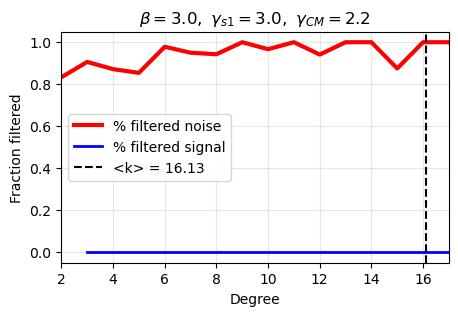

In [13]:
#fig 3

threshold = 95

degrees = np.sort(df_sample['degree'].unique())

perc_filtered_signal = []
perc_filtered_noise = []

for degree in degrees:
    signal_nodes = df_sample[(df_sample['degree'] == degree) & (df_sample['class'] == 1)]
    noise_nodes  = df_sample[(df_sample['degree'] == degree) & (df_sample['class'] == 2)]

    if degree in percentiles[threshold]:
        perc_value = percentiles[threshold][degree]

        # signal (class 1)
        if len(signal_nodes) > 0:
            filtered_signal = np.sum(signal_nodes['clustering'] <= perc_value)
            perc_filtered_signal.append(filtered_signal / len(signal_nodes))
        else:
            perc_filtered_signal.append(np.nan)

        # noise (class 2)
        if len(noise_nodes) > 0:
            filtered_noise = np.sum(noise_nodes['clustering'] <= perc_value)
            perc_filtered_noise.append(filtered_noise / len(noise_nodes))
        else:
            perc_filtered_noise.append(np.nan)

    else:
        perc_filtered_signal.append(np.nan)
        perc_filtered_noise.append(np.nan)

# ---- GRADOS MEDIOS (líneas verticales) ----
# 1) grado medio de toda la red (promedio por nodo)
k_mean_network = df_sample['degree'].mean()

# 2) grado medio de nodos noise (class 2) que están siendo filtrados al 95
noise_all = df_sample[df_sample['class'] == 2].copy()

# marcar filtrados usando el percentil 95 por grado
def is_filtered_noise_row(row):
    k = row['degree']
    return (k in percentiles[threshold]) and (row['clustering'] <= percentiles[threshold][k])

noise_filtered = noise_all[noise_all.apply(is_filtered_noise_row, axis=1)]
k_mean_noise_filtered = noise_filtered['degree'].mean() if len(noise_filtered) > 0 else np.nan

# ---- PLOT ----
plt.figure(figsize=(5, 3))

# lila gruesa continua: noise
plt.plot(
    degrees, perc_filtered_noise,
    color='red', linewidth=3,
    label='% filtered noise'
)

# negra punteada: signal
plt.plot(
    degrees, perc_filtered_signal,
    color='blue', linewidth=2,
    label='% filtered signal'
)



# x = <k> red (punteada)
plt.axvline(
    k_mean_network,
    color='black', linestyle='--', linewidth=1.5,
    label=f'<k> = {k_mean_network:.2f}'
)


#plt.ylim(0, 1.1)
plt.xlim(2, 17)

plt.xlabel('Degree')
plt.ylabel('Fraction filtered')
plt.title( rf'$\beta={beta},\ \gamma_{{s1}}={gamma_s1},\ \gamma_{{CM}}={gamma_cm}$')

plt.legend()
plt.grid(alpha=0.3)
fig3 = plt.gcf()
plt.savefig("fig1b.jpg", dpi=300, bbox_inches="tight")
plt.show()

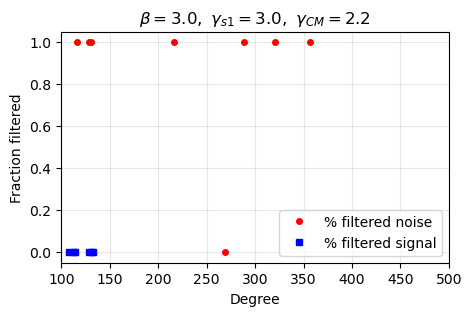

In [35]:
#fig 3

threshold = 95

degrees = np.sort(df_sample['degree'].unique())

perc_filtered_signal = []
perc_filtered_noise = []

for degree in degrees:
    signal_nodes = df_sample[(df_sample['degree'] == degree) & (df_sample['class'] == 1)]
    noise_nodes  = df_sample[(df_sample['degree'] == degree) & (df_sample['class'] == 2)]

    if degree in percentiles[threshold]:
        perc_value = percentiles[threshold][degree]

        # signal (class 1)
        if len(signal_nodes) > 0:
            filtered_signal = np.sum(signal_nodes['clustering'] <= perc_value)
            perc_filtered_signal.append(filtered_signal / len(signal_nodes))
        else:
            perc_filtered_signal.append(np.nan)

        # noise (class 2)
        if len(noise_nodes) > 0:
            filtered_noise = np.sum(noise_nodes['clustering'] <= perc_value)
            perc_filtered_noise.append(filtered_noise / len(noise_nodes))
        else:
            perc_filtered_noise.append(np.nan)

    else:
        perc_filtered_signal.append(np.nan)
        perc_filtered_noise.append(np.nan)

# ---- GRADOS MEDIOS (líneas verticales) ----
# 1) grado medio de toda la red (promedio por nodo)
k_mean_network = df_sample['degree'].mean()

# 2) grado medio de nodos noise (class 2) que están siendo filtrados al 95
noise_all = df_sample[df_sample['class'] == 2].copy()

# marcar filtrados usando el percentil 95 por grado
def is_filtered_noise_row(row):
    k = row['degree']
    return (k in percentiles[threshold]) and (row['clustering'] <= percentiles[threshold][k])

noise_filtered = noise_all[noise_all.apply(is_filtered_noise_row, axis=1)]
k_mean_noise_filtered = noise_filtered['degree'].mean() if len(noise_filtered) > 0 else np.nan

# ---- PLOT ----
plt.figure(figsize=(5, 3))
plt.plot(
    degrees, perc_filtered_noise,
    marker='o',
    linestyle='None',
    color='red',
    markersize=4,
    label='% filtered noise'
)

# signal: puntos azules
plt.plot(
    degrees, perc_filtered_signal,
    marker='s',
    linestyle='None',
    color='blue',
    markersize=4,
    label='% filtered signal'
)


#plt.ylim(0, 1.1)
plt.xlim(100,500)

plt.xlabel('Degree')
plt.ylabel('Fraction filtered')
plt.title( rf'$\beta={beta},\ \gamma_{{s1}}={gamma_s1},\ \gamma_{{CM}}={gamma_cm}$')

plt.legend()
plt.grid(alpha=0.3)
fig3 = plt.gcf()
plt.savefig("fig1c.jpg", dpi=300, bbox_inches="tight")
plt.show()

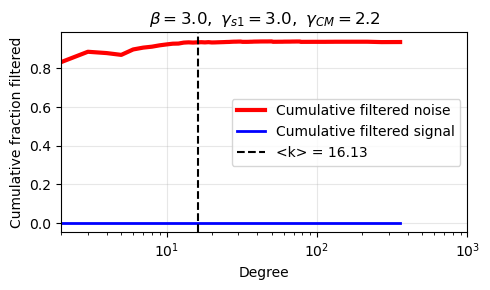

In [14]:
# --- FIGURE 3: CUMULATIVE FILTERED FRACTION ---

threshold = 95

degrees = np.sort(df_sample['degree'].unique())

# --- COUNT ARRAYS ---
filtered_signal_counts = []
total_signal_counts = []

filtered_noise_counts = []
total_noise_counts = []

for degree in degrees:
    signal_nodes = df_sample[(df_sample['degree'] == degree) & (df_sample['class'] == 1)]
    noise_nodes  = df_sample[(df_sample['degree'] == degree) & (df_sample['class'] == 2)]

    if degree in percentiles[threshold]:
        perc_value = percentiles[threshold][degree]

        # signal (class 1)
        filtered_signal_counts.append(np.sum(signal_nodes['clustering'] <= perc_value))
        total_signal_counts.append(len(signal_nodes))

        # noise (class 2)
        filtered_noise_counts.append(np.sum(noise_nodes['clustering'] <= perc_value))
        total_noise_counts.append(len(noise_nodes))
    else:
        filtered_signal_counts.append(0)
        total_signal_counts.append(0)
        filtered_noise_counts.append(0)
        total_noise_counts.append(0)

# --- CUMULATIVE FRACTIONS ---
filtered_signal_counts = np.array(filtered_signal_counts)
total_signal_counts    = np.array(total_signal_counts)

filtered_noise_counts = np.array(filtered_noise_counts)
total_noise_counts    = np.array(total_noise_counts)

# Avoid division by zero
cum_signal = np.divide(
    np.cumsum(filtered_signal_counts),
    np.cumsum(total_signal_counts),
    out=np.zeros_like(filtered_signal_counts, dtype=float),
    where=np.cumsum(total_signal_counts) != 0
)

cum_noise = np.divide(
    np.cumsum(filtered_noise_counts),
    np.cumsum(total_noise_counts),
    out=np.zeros_like(filtered_noise_counts, dtype=float),
    where=np.cumsum(total_noise_counts) != 0
)

# --- MEAN DEGREE LINES ---
k_mean_network = df_sample['degree'].mean()

noise_all = df_sample[df_sample['class'] == 2].copy()

def is_filtered_noise_row(row):
    k = row['degree']
    return (k in percentiles[threshold]) and (row['clustering'] <= percentiles[threshold][k])

noise_filtered = noise_all[noise_all.apply(is_filtered_noise_row, axis=1)]
k_mean_noise_filtered = noise_filtered['degree'].mean() if len(noise_filtered) > 0 else np.nan

# --- PLOT ---
plt.figure(figsize=(5, 3))

# cumulative noise (red, thick)
plt.plot(
    degrees, cum_noise,
    color='red', linewidth=3,
    label='Cumulative filtered noise'
)

# cumulative signal (blue)
plt.plot(
    degrees, cum_signal,
    color='blue', linewidth=2,
    label='Cumulative filtered signal'
)

# vertical line: mean degree of network
plt.axvline(
    k_mean_network,
    color='black', linestyle='--', linewidth=1.5,
    label=f'<k> = {k_mean_network:.2f}'
)

# --- AXES & STYLE ---
plt.xlim(2, 1000)
plt.xscale('log')
plt.xlabel('Degree')
plt.ylabel('Cumulative fraction filtered')

plt.title(rf'$\beta={beta},\ \gamma_{{s1}}={gamma_s1},\ \gamma_{{CM}}={gamma_cm}$')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig3_cumulative.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# Define the function once
def save_feat_inside_percentile(df_sample, threshold):
    # Check if the column exists
    column_name = f'within_{threshold}'
    if column_name not in df_sample.columns:
        print(f"La columna '{column_name}' no existe en el DataFrame.")
        return

    # Filter nodes within the percentile
    feat_inside_percentile = df_sample[df_sample[column_name]]['node'].values

    # Create a DataFrame with nodes within the percentile
    df_inside_percentile = pd.DataFrame(feat_inside_percentile, columns=['node'])

    # Save the DataFrame to a file
    output_file = f'features_{threshold}.dat'
    df_inside_percentile.to_csv(output_file, sep='\t', index=False, header=False)

   # print(f"Archivo '{output_file}' generado con éxito.")

# List of threshold values
thresholds = [50,55,60, 65, 70, 75, 80, 85, 90, 95, 99, 99.9,100]

# Loop through the threshold values
for threshold in thresholds:
    save_feat_inside_percentile(df_sample, threshold)

La columna 'within_50' no existe en el DataFrame.
La columna 'within_55' no existe en el DataFrame.
La columna 'within_60' no existe en el DataFrame.
La columna 'within_65' no existe en el DataFrame.
La columna 'within_70' no existe en el DataFrame.
La columna 'within_75' no existe en el DataFrame.
La columna 'within_80' no existe en el DataFrame.
La columna 'within_85' no existe en el DataFrame.
La columna 'within_90' no existe en el DataFrame.
La columna 'within_95' no existe en el DataFrame.
La columna 'within_99' no existe en el DataFrame.
La columna 'within_99.9' no existe en el DataFrame.
La columna 'within_100' no existe en el DataFrame.


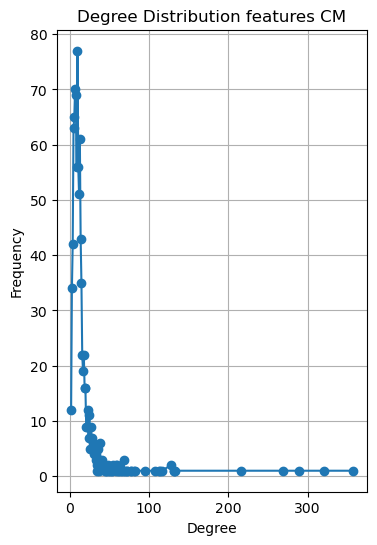

In [22]:

# Obtener la degree distribution de los nodos de clase 2
degree_distribution = df_sample['degree'].value_counts().sort_index()

# Graficar la degree distribution como una curva
plt.figure(figsize=(4, 6))
plt.plot(degree_distribution.index, degree_distribution.values, marker='o', linestyle='-')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Degree Distribution features CM')
plt.grid(True)
plt.show()

# Guardar la degree distribution en un archivo dat
degree_distribution.to_csv('degree_distribution_original.dat', sep=' ', header=False)

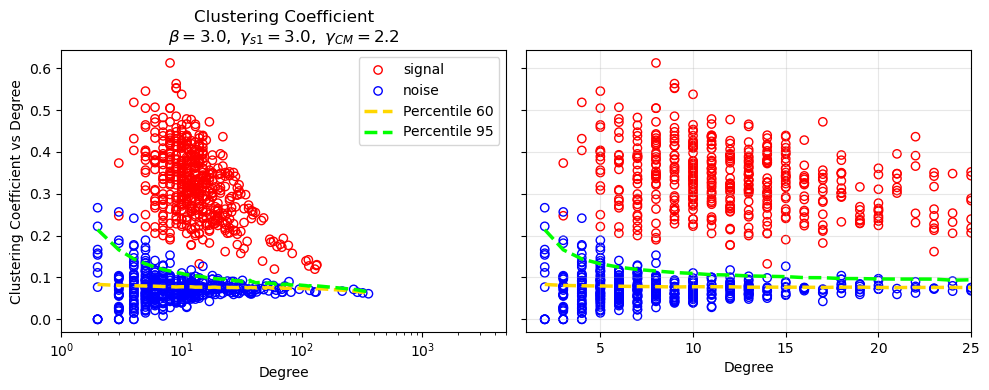

In [34]:
#fig 4

colors = {
    60: '#FFD700',  # bright gold / yellow
    95: '#00FF00'   # neon green
}


# --------- 1) Parameters ---------
pvalues = [60, 95]
percentiles_file = 'percentiles_sample.dat'

# --------- 2) Load sample ---------
sample_file = 'clustering_sample1.dat'
df_sample = pd.read_csv(sample_file, delim_whitespace=True, header=None,
                        names=['node', 'class', 'degree', 'clustering'])

df_sample['degree'] = pd.to_numeric(df_sample['degree'], errors='coerce')
df_sample['clustering'] = pd.to_numeric(df_sample['clustering'], errors='coerce')

# --------- 3) Compute percentiles by degree (from df_rewiring) ---------
degrees_of_interest = df_rewiring['degree'].unique()

percentiles_list = []
for degree in degrees_of_interest:
    clustering_values = df_rewiring.loc[
        df_rewiring['degree'] == degree, 'clustering'
    ].dropna().values

    if clustering_values.size == 0:
        continue

    row = {'degree': degree}
    for p in pvalues:
        row[f'percentile_{p}'] = np.percentile(clustering_values, p)

    percentiles_list.append(row)

percentiles_df = pd.DataFrame(percentiles_list)

percentiles_df['degree'] = pd.to_numeric(percentiles_df['degree'], errors='coerce')
percentiles_df.sort_values('degree', inplace=True)

# --------- 4) Save percentiles to .dat ---------
cols_to_save = ['degree'] + [f'percentile_{p}' for p in pvalues]
percentiles_df.to_csv(percentiles_file, sep='\t',
                      index=False, header=False, columns=cols_to_save)

# --------- 5) Reload percentiles for plotting ---------
colnames = ['degree'] + [f'percentile_{p}' for p in pvalues]
df_percentiles = pd.read_csv(percentiles_file, delim_whitespace=True,
                             header=None, names=colnames)

df_percentiles['degree'] = pd.to_numeric(df_percentiles['degree'], errors='coerce')
for p in pvalues:
    df_percentiles[f'percentile_{p}'] = pd.to_numeric(
        df_percentiles[f'percentile_{p}'], errors='coerce'
    )

df_percentiles.sort_values('degree', inplace=True)

# --------- 6) Filter by class ---------
class_1_data = df_sample[df_sample['class'] == 1]
class_2_data = df_sample[df_sample['class'] == 2]

# --------- 7) Plot: full range + zoom ---------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# ---- Left: full range ----
axes[0].scatter(class_1_data['degree'], class_1_data['clustering'],
                edgecolor='red', facecolor='none', label='signal')
axes[0].scatter(class_2_data['degree'], class_2_data['clustering'],
                edgecolor='blue', facecolor='none', label='noise')

for p in pvalues:
    axes[0].plot(df_percentiles['degree'],
                 df_percentiles[f'percentile_{p}'],
                 linestyle='dashed',color=colors[p],linewidth=2.5,label=f'Percentile {p}')
axes[0].set_xscale('log')   
axes[0].set_xlim(1, 5000)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Clustering Coefficient vs Degree')
axes[0].set_title(
    rf'Clustering Coefficient'
    '\n'
    rf'$\beta={beta},\ \gamma_{{s1}}={gamma_s1},\ \gamma_{{CM}}={gamma_cm}$'
)

axes[0].legend()

# ---- Right: zoom ----
axes[1].scatter(class_1_data['degree'], class_1_data['clustering'],
                edgecolor='red', facecolor='none')
axes[1].scatter(class_2_data['degree'], class_2_data['clustering'],
                edgecolor='blue', facecolor='none')

for p in pvalues:
    axes[1].plot(df_percentiles['degree'],
                 df_percentiles[f'percentile_{p}'],
                 linestyle='dashed',color=colors[p],linewidth=2.5)

axes[1].set_xlim(1, 25)
axes[1].set_xlabel('Degree')
#axes[1].set_title('Zoom: 2–25')
axes[1].grid(alpha=0.3)
#axes[1].legend()

plt.tight_layout()
fig4 = plt.gcf()
plt.show()

In [24]:


# Greek letters directly in filename
output_pdf = f"figs_β={beta}_γS1={gamma_s1}_γCM={gamma_cm}.pdf"

with PdfPages(output_pdf) as pdf:
    for i, fig in enumerate([fig1, fig2_signal, fig2_noise, fig3, fig4], start=1):
        fig.text(0.01, 0.99, f"Fig. {i}", ha="left", va="top", fontsize=14)
        pdf.savefig(fig, bbox_inches="tight")

print(f"Saved: {output_pdf}")

Saved: figs_β=3.0_γS1=3.0_γCM=2.2.pdf


In [4]:
sample0 = pd.read_csv('sample_d0.dat', sep='\t', header=None, names=['node', 'feature'])

# Define the list of percentiles to iterate over
percentiles = [60, 65, 70, 75, 80, 85, 90, 95, 99, 99.9]

# Loop through each percentile and process accordingly
for percentile in percentiles:
    # Load the corresponding features_XX.dat file
    features_file = f'features_{percentile}.dat'
    features_inside = pd.read_csv(features_file, sep='\t', header=None, names=['feature'])
    
    # Filter sample0 based on the features in the current percentile file
    filtered_sample0 = sample0[sample0['feature'].isin(features_inside['feature'])]
    
    # Save the filtered data to a new file named according to the current percentile
    output_file = f'sample0_noise_{percentile}_it1.dat'
    filtered_sample0.to_csv(output_file, sep='\t', index=False, header=False)
    
    print(f"Archivo '{output_file}' generado con éxito.")


Archivo 'sample0_noise_60_it1.dat' generado con éxito.
Archivo 'sample0_noise_65_it1.dat' generado con éxito.
Archivo 'sample0_noise_70_it1.dat' generado con éxito.
Archivo 'sample0_noise_75_it1.dat' generado con éxito.
Archivo 'sample0_noise_80_it1.dat' generado con éxito.
Archivo 'sample0_noise_85_it1.dat' generado con éxito.
Archivo 'sample0_noise_90_it1.dat' generado con éxito.
Archivo 'sample0_noise_95_it1.dat' generado con éxito.
Archivo 'sample0_noise_99_it1.dat' generado con éxito.
Archivo 'sample0_noise_99.9_it1.dat' generado con éxito.


In [25]:
sample0 = pd.read_csv('BlogCatalog_bipartite.dat', sep='\t', header=None, names=['node', 'feature'])

# Define the list of percentiles to iterate over
percentiles = [60, 65, 70, 75, 80, 85, 90, 95, 99, 99.9]

# Loop through each percentile and process accordingly
for percentile in percentiles:
    # Load the corresponding features_XX.dat file
    features_file = f'features_{percentile}.dat'
    features_inside = pd.read_csv(features_file, sep='\t', header=None, names=['feature'])
    
    # Filter sample0 based on the features in the current percentile file
    filtered_sample0 = sample0[~sample0['feature'].isin(features_inside['feature'])]

    
    # Save the filtered data to a new file named according to the current percentile
    output_file = f'BlogCatalog_{percentile}_it1.dat'
    filtered_sample0.to_csv(output_file, sep='\t', index=False, header=False)
    
    print(f"Archivo '{output_file}' generado con éxito.")

Archivo 'BlogCatalog_60_it1.dat' generado con éxito.
Archivo 'BlogCatalog_65_it1.dat' generado con éxito.
Archivo 'BlogCatalog_70_it1.dat' generado con éxito.
Archivo 'BlogCatalog_75_it1.dat' generado con éxito.
Archivo 'BlogCatalog_80_it1.dat' generado con éxito.
Archivo 'BlogCatalog_85_it1.dat' generado con éxito.
Archivo 'BlogCatalog_90_it1.dat' generado con éxito.
Archivo 'BlogCatalog_95_it1.dat' generado con éxito.
Archivo 'BlogCatalog_99_it1.dat' generado con éxito.
Archivo 'BlogCatalog_99.9_it1.dat' generado con éxito.
